In [7]:
%load_ext autoreload
%autoreload 2


import ipywidgets as widgets
import sys
from pathlib import Path
import os
import importlib


module_path='preprocessing/day_intervals_preproc'
if module_path not in sys.path:
    sys.path.append(module_path)

module_path='utils'
if module_path not in sys.path:
    sys.path.append(module_path)
    
module_path='preprocessing/hosp_module_preproc'
if module_path not in sys.path:
    sys.path.append(module_path)
    
module_path='model'
if module_path not in sys.path:
    sys.path.append(module_path)
#print(sys.path)
root_dir = os.path.dirname(os.path.abspath('UserInterface.ipynb'))
import day_intervals_cohort
from day_intervals_cohort import *

import day_intervals_cohort_v2
from day_intervals_cohort_v2 import *

import data_generation_icu

import data_generation
import evaluation

import feature_selection_hosp
from feature_selection_hosp import *

# import train
# from train import *


import ml_models
from ml_models import *

import dl_train
from dl_train import *

import tokenization
from tokenization import *


import behrt_train
from behrt_train import *

import feature_selection_icu
from feature_selection_icu import *
import fairness
import callibrate_output

importlib.reload(day_intervals_cohort)
import day_intervals_cohort
from day_intervals_cohort import *

importlib.reload(day_intervals_cohort_v2)
import day_intervals_cohort_v2
from day_intervals_cohort_v2 import *

importlib.reload(data_generation_icu)
import data_generation_icu
importlib.reload(data_generation)
import data_generation

importlib.reload(feature_selection_hosp)
import feature_selection_hosp
from feature_selection_hosp import *

importlib.reload(feature_selection_icu)
import feature_selection_icu
from feature_selection_icu import *

importlib.reload(tokenization)
import tokenization
from tokenization import *

importlib.reload(ml_models)
import ml_models
from ml_models import *

importlib.reload(dl_train)
import dl_train
from dl_train import *

importlib.reload(behrt_train)
import behrt_train
from behrt_train import *

importlib.reload(fairness)
import fairness

importlib.reload(callibrate_output)
import callibrate_output

importlib.reload(evaluation)
import evaluation


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load each CSV file
demo_all = pd.read_csv('data/csv/demo_all.csv')
dynamic_all = pd.read_csv('data/csv/dynamic_all.csv')
labels = pd.read_csv('data/csv/labels.csv')
static_all = pd.read_csv('data/csv/static_all.csv')

# Display first few rows to confirm structure
print("Demo data sample:")
print(demo_all.head())
print("\nDynamic data sample:")
print(dynamic_all.head())
print("\nLabels data sample:")
print(labels.head())
print("\nStatic data sample:")
print(static_all.head())

# Merge datasets on common identifiers
data_merged = labels.merge(demo_all, left_on='stay_id', right_on='hid', how='inner') \
                    .merge(dynamic_all, left_on='stay_id', right_on='ids', how='inner') \
                    .merge(static_all, left_on='stay_id', right_on='ids', how='inner')

# Drop duplicate columns from merging and remove the 'insurance' column
data_merged = data_merged.drop(columns=['hid_x', 'hid_y', 'ids_x', 'ids_y', 'insurance'], errors='ignore')

# # Step 4: Standardize numerical features
# scaler = StandardScaler()
# numerical_columns = data_merged.select_dtypes(include=['float64', 'int64']).columns
# data_merged[numerical_columns] = scaler.fit_transform(data_merged[numerical_columns])

# Encode gender and ethnicity using label encoding
label_encoder_gender = LabelEncoder()
label_encoder_ethnicity = LabelEncoder()

data_merged['gender'] = label_encoder_gender.fit_transform(data_merged['gender'])
data_merged['ethnicity'] = label_encoder_ethnicity.fit_transform(data_merged['ethnicity'])



# Define target and features
y = data_merged['label']  # Target variable
X = data_merged.drop(columns=['label', 'stay_id'])  # Features, excluding non-feature columns

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Confirm shape of splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)




C:\Users\darsh\AppData\Local\Temp\ipykernel_99248\2113833943.py:7: DtypeWarning: Columns (126) have mixed types. Specify dtype option on import or set low_memory=False.
  dynamic_all = pd.read_csv('data/csv/dynamic_all.csv')
C:\Users\darsh\AppData\Local\Temp\ipykernel_99248\2113833943.py:9: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198

Demo data sample:
   Age gender ethnicity insurance       hid
0   46      F     WHITE     Other  31205490
1   77      F     WHITE  Medicare  32610785
2   78      M     WHITE  Medicare  32155744
3   52      M   UNKNOWN  Medicaid  34617352
4   26      F     WHITE     Other  31959184

Dynamic data sample:
       MEDS    MEDS.1    MEDS.2    MEDS.3    MEDS.4    MEDS.5    MEDS.6  \
0  225158.0  225943.0  229234.0  229624.0  221749.0  220949.0  222056.0   
1      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   
2      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   
3      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   
4      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   

     MEDS.7    MEDS.8    MEDS.9  ...  MEDS.117  MEDS.118  MEDS.119  MEDS.120  \
0  225151.0  225152.0  225823.0  ...  229764.0  229618.0  221385.0  229013.0   
1       0.0       0.0       0.0  ...       0.0       0.0       0.0       0.0   
2    

In [2]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
import shap
import matplotlib.pyplot as plt

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
}

# Store performance metrics
performance_metrics = {}

# Hyperparameter tuning for Random Forest and Gradient Boosting
param_grids = {
    "Random Forest": {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    "Gradient Boosting": {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}
}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Hyperparameter tuning (for Random Forest and Gradient Boosting)
    if model_name in param_grids:
        grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
    else:
        model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluate model
    performance_metrics[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AU-ROC": roc_auc_score(y_test, y_proba),
        "F1 Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }
    print(f"{model_name} performance:")
    for metric, value in performance_metrics[model_name].items():
        print(f"{metric}: {value:.4f}")
    print("\n" + "="*30 + "\n")



# Select the best model based on AU-ROC score
best_model_name = max(performance_metrics, key=lambda x: performance_metrics[x]["AU-ROC"])
best_model = models[best_model_name]

# Ensure the model is trained before SHAP analysis
if not hasattr(best_model, "estimators_"):
    best_model.fit(X_train, y_train)  # Train the model if not already done

Training Logistic Regression...


c:\Users\darsh\Desktop\MIMIC-IV-Data-Pipeline\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression performance:
Accuracy: 0.7154
AU-ROC: 0.6398
F1 Score: 0.2442
Precision: 0.1728
Recall: 0.4161


Training Random Forest...
Random Forest performance:
Accuracy: 0.9856
AU-ROC: 0.9962
F1 Score: 0.9349
Precision: 0.9329
Recall: 0.9368


Training Gradient Boosting...
Gradient Boosting performance:
Accuracy: 0.9245
AU-ROC: 0.9315
F1 Score: 0.5240
Precision: 0.8625
Recall: 0.3763




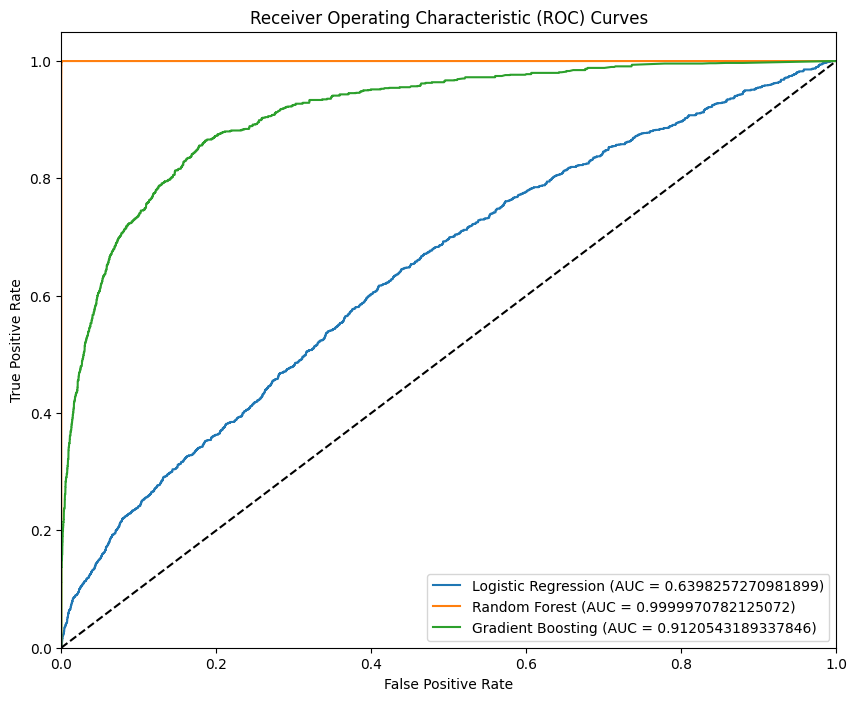

In [3]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Plotting AU-ROC curves for each model
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    # Ensure each model is fitted before predicting probabilities
    if not hasattr(model, "estimators_") and model_name != "Logistic Regression":
        model.fit(X_train, y_train)  # Fit the model if not already done

    # Check if the model supports predict_proba
    if hasattr(model, "predict_proba"):
        # Generate probabilities for the positive class
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Use decision_function as a fallback (for models like SVM without predict_proba)
        y_scores = model.decision_function(X_test)
        y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())  # Scale to [0,1]

    # Calculate the ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve with full precision for AUC
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc})")

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curves")
plt.legend(loc="lower right")
plt.show()


In [4]:
import shap
from interpret import show
from interpret.blackbox import ShapKernel
from interpret.blackbox import LimeTabular
from interpret.blackbox import PartialDependence

gb_shap = ShapKernel(best_model, shap.sample(X_train, 100))
gb_shap_local = gb_shap.explain_local(X_test[:100], y_test[:100])
show(gb_shap_local)

  0%|          | 0/100 [00:00<?, ?it/s]

<!-- http://127.0.0.1:7678/2484287294768/ -->

KS Statistic: 0.19, P-value: 3.4297459018708595e-16


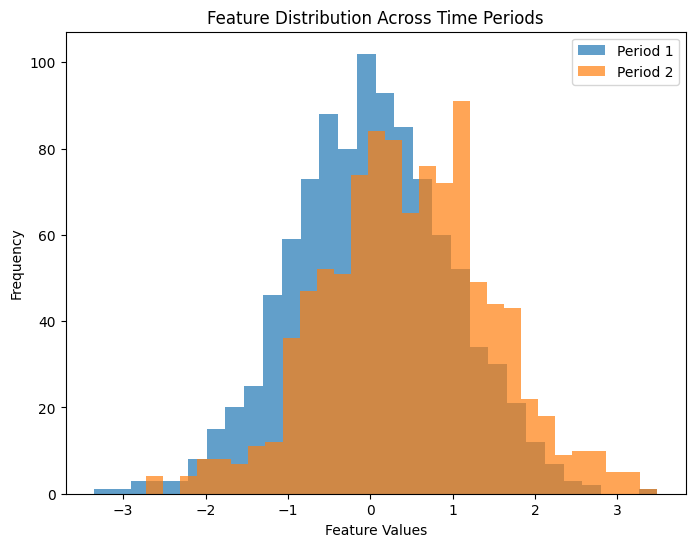

In [8]:
#Data Shift Analysis

from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

# Replace with actual features and data subsets from different time periods
data_period1 = pd.DataFrame({'feature': np.random.normal(0, 1, 1000)})
data_period2 = pd.DataFrame({'feature': np.random.normal(0.5, 1, 1000)})

# Perform KS test
ks_stat, p_value = ks_2samp(data_period1['feature'], data_period2['feature'])
print(f"KS Statistic: {ks_stat}, P-value: {p_value}")

# Visualize the distributions
plt.figure(figsize=(8, 6))
plt.hist(data_period1['feature'], bins=30, alpha=0.7, label="Period 1")
plt.hist(data_period2['feature'], bins=30, alpha=0.7, label="Period 2")
plt.title("Feature Distribution Across Time Periods")
plt.xlabel("Feature Values")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [10]:
#Fairness Analsis
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

# Replace with actual data
df = pd.DataFrame({
    'feature1': np.random.rand(1000),
    'feature2': np.random.randint(0, 2, 1000),
    'label': np.random.randint(0, 2, 1000)
})
privileged_groups = [{'feature2': 1}]  # E.g., males
unprivileged_groups = [{'feature2': 0}]  # E.g., females

# Convert to BinaryLabelDataset
dataset = BinaryLabelDataset(df=df, label_names=['label'], protected_attribute_names=['feature2'])

# Fairness metrics
metric = BinaryLabelDatasetMetric(dataset, unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
print(f"Disparate Impact: {metric.disparate_impact()}")


Disparate Impact: 1.0556236592093164


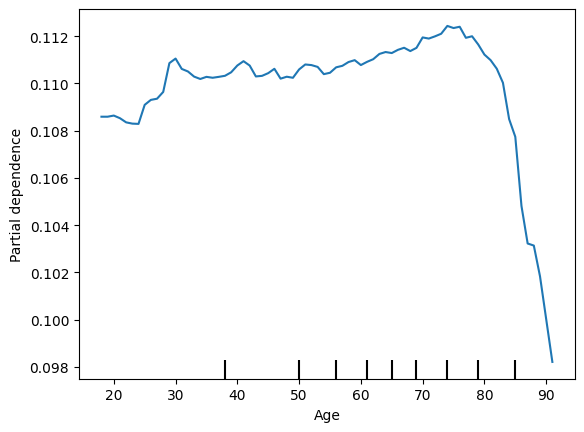

In [11]:
from sklearn.inspection import PartialDependenceDisplay

# Example: PDP for feature 1
PartialDependenceDisplay.from_estimator(best_model, X_train, [0])
plt.show()



Distribution Shift Results (Age, Gender, Ethnicity):
Feature: Age
  KS Statistic: 0.0234
  p-value: 0.0169

Feature: gender
  Chi-Square Statistic: 1.3604
  p-value: 0.2435

Feature: ethnicity
  Chi-Square Statistic: 1425.9417
  p-value: 0.0000



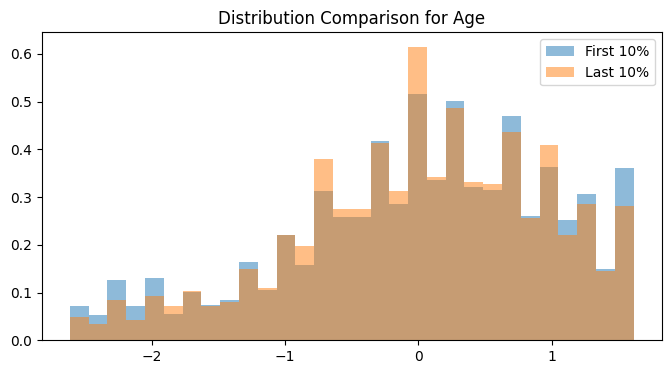

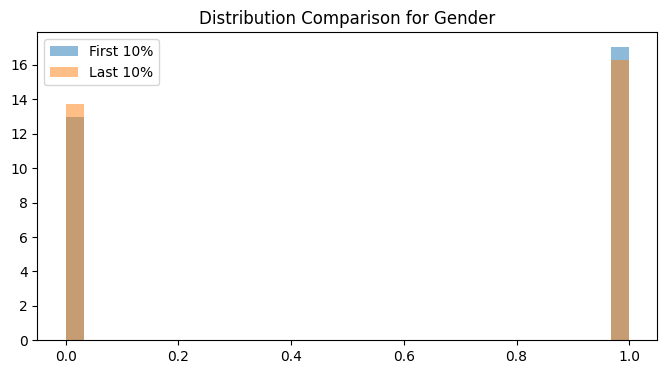

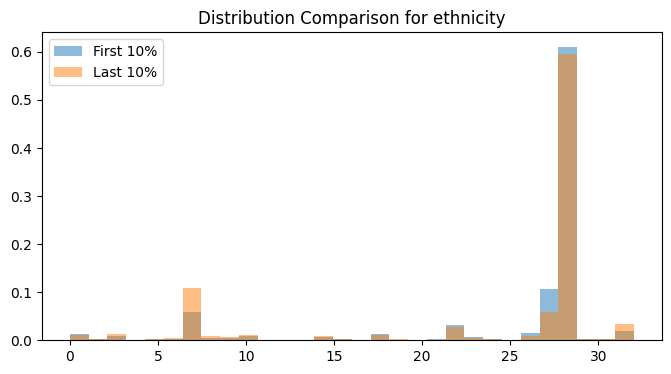

In [23]:
from scipy.stats import ks_2samp, chi2_contingency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load datasets
demo_first = pd.read_csv('data/csv/demo_all.csv')
labels_first = pd.read_csv('data/csv/labels.csv')

demo_last = pd.read_csv('data/csv10/demo_all-last10.csv')
labels_last = pd.read_csv('data/csv10/labels-last10.csv')

# Merge datasets
data_first = labels_first.merge(demo_first, left_on='stay_id', right_on='hid', how='inner')
data_last = labels_last.merge(demo_last, left_on='stay_id', right_on='hid', how='inner')

# Focus on relevant columns: Age, Gender, Ethnicity
columns_to_keep = ['Age', 'gender', 'ethnicity']
data_first = data_first[columns_to_keep]
data_last = data_last[columns_to_keep]

# Standardize Age and encode Gender/Ethnicity
scaler = StandardScaler()
data_first['Age'] = scaler.fit_transform(data_first[['Age']])
data_last['Age'] = scaler.transform(data_last[['Age']])

label_encoder_gender = LabelEncoder()
label_encoder_ethnicity = LabelEncoder()

for data in [data_first, data_last]:
    data['gender'] = label_encoder_gender.fit_transform(data['gender'])
    data['ethnicity'] = label_encoder_ethnicity.fit_transform(data['ethnicity'])

# Define function to measure distribution shift for selected features
def measure_shift(data1, data2):
    shift_results = {}

    # Numerical Feature - Age (KS Test)
    ks_stat, ks_pval = ks_2samp(data1['Age'], data2['Age'])
    shift_results['Age'] = {"KS Statistic": ks_stat, "p-value": ks_pval}

    # Categorical Features - Gender and Ethnicity (Chi-Square Test)
    for col in ['gender', 'ethnicity']:
        contingency_table = pd.crosstab(data1[col], data2[col])
        chi2_stat, chi2_pval, _, _ = chi2_contingency(contingency_table)
        shift_results[col] = {"Chi-Square Statistic": chi2_stat, "p-value": chi2_pval}

    return shift_results

# Measure shift
shift_results = measure_shift(data_first, data_last)

# Display results
print("\nDistribution Shift Results (Age, Gender, Ethnicity):")
for feature, stats in shift_results.items():
    print(f"Feature: {feature}")
    for metric, value in stats.items():
        print(f"  {metric}: {value:.4f}")
    print()

# Visualize Age distribution shift
plt.figure(figsize=(8, 4))
plt.hist(data_first['Age'], bins=30, alpha=0.5, label="First 10%", density=True)
plt.hist(data_last['Age'], bins=30, alpha=0.5, label="Last 10%", density=True)
plt.title("Distribution Comparison for Age")
plt.legend()
plt.show()

# Visualize Gender distribution shift
plt.figure(figsize=(8, 4))
plt.hist(data_first['gender'], bins=30, alpha=0.5, label="First 10%", density=True)
plt.hist(data_last['gender'], bins=30, alpha=0.5, label="Last 10%", density=True)
plt.title("Distribution Comparison for Gender")
plt.legend()
plt.show()

# Visualize Ethnicity distribution shift
plt.figure(figsize=(8, 4))
plt.hist(data_first['ethnicity'], bins=30, alpha=0.5, label="First 10%", density=True)
plt.hist(data_last['ethnicity'], bins=30, alpha=0.5, label="Last 10%", density=True)
plt.title("Distribution Comparison for ethnicity")
plt.legend()
plt.show()


In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

def calculate_fairness_metrics(y_true, y_pred, sensitive_attribute):
    """
    Calculate fairness metrics based on sensitive attributes (e.g., gender, ethnicity).
    """
    groups = np.unique(sensitive_attribute)
    fairness_metrics = {}
    
    for group in groups:
        mask = sensitive_attribute == group
        cm = confusion_matrix(y_true[mask], y_pred[mask])
        tn, fp, fn, tp = cm.ravel()
        
        group_metrics = {
            "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
            "Recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
            "False Positive Rate": fp / (fp + tn) if (fp + tn) > 0 else 0,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) > 0 else 0
        }
        fairness_metrics[group] = group_metrics
    
    return fairness_metrics

# Example usage:
# Replace `y_test`, `y_pred`, and `sensitive_attribute` with your actual data.
fairness_results = calculate_fairness_metrics(y_test, y_pred, X_test['gender'])
print(fairness_results)


{0: {'Precision': 0.8846153846153846, 'Recall': 0.3788235294117647, 'False Positive Rate': 0.006446661550268611, 'False Negative Rate': 0.6211764705882353}, 1: {'Precision': 0.8449781659388647, 'Recall': 0.3742746615087041, 'False Positive Rate': 0.008204298590247284, 'False Negative Rate': 0.625725338491296}}
